# Statistical Significance Testing: PPI Input vs CPIH

This notebook validates whether UK producer input price inflation (`ppi_input_yoy`) has statistically significant predictive power for consumer inflation (`cpih_yoy`).

It is intended as a **mechanism check** for the team's wider story. It does **not** directly test whether the Ukraine war dummy causes inflation; instead, it tests whether upstream producer-price pressure helps predict downstream CPIH inflation.

Key guardrails for interpretation:
- Granger causality means incremental **predictive content**, not proof of structural causality.
- A significant result supports a transmission channel from producer costs to consumer inflation.
- A non-significant reverse test strengthens the directionality claim, but still does not prove economic causation by itself.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

DATA_FILE = "master_table_v2_uk_inflation_war_baseline_with_ppi.csv"


def resolve_data_path(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "Analysis Datasets" / filename,
        Path.cwd().parent / "Analysis Datasets" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not locate {filename}. Checked: {candidates}")


def adf_pvalue(series: pd.Series) -> float:
    clean = series.dropna()
    return adfuller(clean)[1]


def granger_pvalues(data: pd.DataFrame, max_lag: int) -> list[float]:
    results = grangercausalitytests(data, maxlag=max_lag, verbose=False)
    return [results[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag + 1)]


In [9]:
data_path = resolve_data_path(DATA_FILE)
fig_path = data_path.with_name("fig_granger_validation_improved.png")

df = pd.read_csv(data_path, parse_dates=["date"]).sort_values("date")
required_cols = ["cpih_yoy", "ppi_input_yoy"]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

pair = df[["date", "cpih_yoy", "ppi_input_yoy"]].dropna().copy()
pair = pair.set_index("date")
diff_pair = pair.diff().dropna()

print(f"Data path: {data_path.name}")
print(f"Rows used in level analysis: {len(pair)}")
print(f"Rows used after differencing: {len(diff_pair)}")
print(f"Date range: {pair.index.min().date()} to {pair.index.max().date()}")
pair.head()


Data path: master_table_v2_uk_inflation_war_baseline_with_ppi.csv
Rows used in level analysis: 254
Rows used after differencing: 253
Date range: 2005-01-01 to 2026-02-01


,cpih_yoy,ppi_input_yoy
date,,
2005-01-01,1.7,6.855440
2005-02-01,1.7,7.313433
2005-03-01,2.0,7.090103
2005-04-01,1.9,7.079646
2005-05-01,1.9,6.122449


In [10]:
stationarity_summary = pd.DataFrame(
    {
        "ADF p-value (level)": {
            "cpih_yoy": adf_pvalue(pair["cpih_yoy"]),
            "ppi_input_yoy": adf_pvalue(pair["ppi_input_yoy"]),
        },
        "ADF p-value (first difference)": {
            "cpih_yoy": adf_pvalue(diff_pair["cpih_yoy"]),
            "ppi_input_yoy": adf_pvalue(diff_pair["ppi_input_yoy"]),
        },
    }
)

lag_selection = VAR(diff_pair).select_order(12)
lag_summary = pd.DataFrame([lag_selection.selected_orders])

display(stationarity_summary.style.format("{:.6f}"))
display(lag_summary)

print("Interpretation:")
print("- CPIH is not comfortably stationary in levels, so differencing is appropriate here.")
print("- Both differenced series pass the ADF check at conventional thresholds.")
print("- We report Granger tests for lags 1 to 12 and use lag-order selection as context, not as the only decision rule.")


d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,ADF p-value (level),ADF p-value (first difference)
cpih_yoy,0.140727,0.000007
ppi_input_yoy,0.004130,0.001176


,aic,bic,hqic,fpe
0,12,1,12,12


Interpretation:
- CPIH is not comfortably stationary in levels, so differencing is appropriate here.
- Both differenced series pass the ADF check at conventional thresholds.
- We report Granger tests for lags 1 to 12 and use lag-order selection as context, not as the only decision rule.


d:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


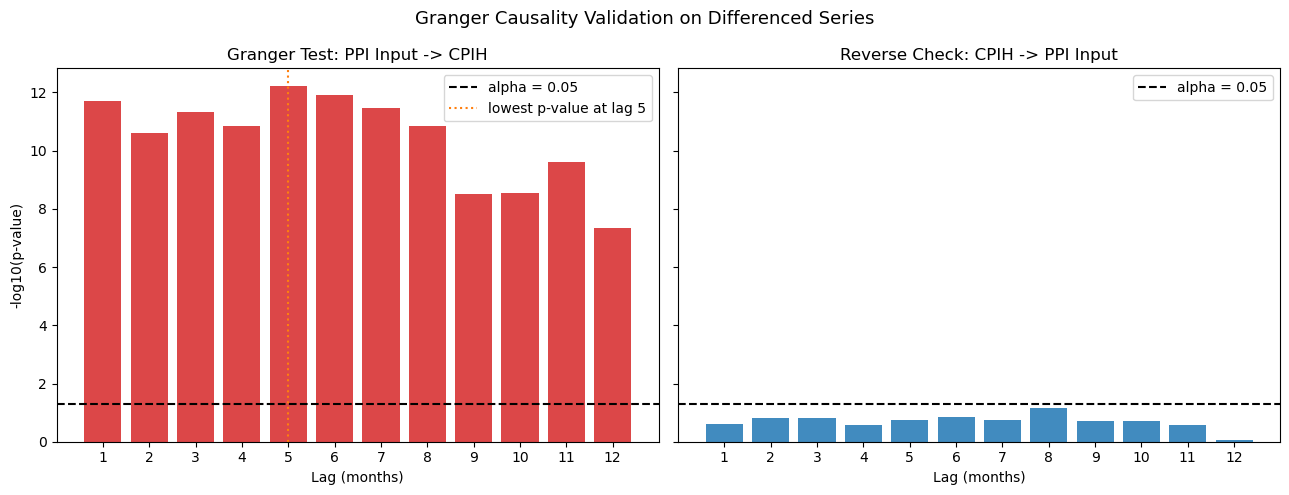

,lag_months,PPI -> CPIH p-value,CPIH -> PPI p-value,PPI -> CPIH significant,CPIH -> PPI significant
0,1,2.01756e-12,0.245159,True,False
1,2,2.47081e-11,0.153668,True,False
2,3,4.80618e-12,0.153672,True,False
3,4,1.43037e-11,0.275132,True,False
4,5,6.08188e-13,0.181432,True,False
5,6,1.21754e-12,0.140301,True,False
6,7,3.45702e-12,0.185953,True,False
7,8,1.37588e-11,0.0669805,True,False
8,9,3.12535e-09,0.195647,True,False
9,10,2.88531e-09,0.201247,True,False


Conclusion for reporting:
- PPI Input -> CPIH is statistically significant in the joint Granger test for lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12].
- The lowest forward-direction p-value occurs at lag 5.
- Reverse-direction significant lags: none.
- This supports a producer-cost transmission channel into CPIH, but it should be presented as predictive evidence rather than proof of structural causality.
- This notebook does not directly estimate the war dummy effect; it complements the project's war-related analysis rather than replacing it.
- Figure saved to: fig_granger_validation_improved.png


In [11]:
max_lag = 12
lags = np.arange(1, max_lag + 1)
threshold = -np.log10(0.05)

# In statsmodels' grangercausalitytests, the second column is tested as a predictor of the first.
forward_data = diff_pair[["cpih_yoy", "ppi_input_yoy"]]
reverse_data = diff_pair[["ppi_input_yoy", "cpih_yoy"]]

forward_p = granger_pvalues(forward_data, max_lag)
reverse_p = granger_pvalues(reverse_data, max_lag)

results_df = pd.DataFrame(
    {
        "lag_months": lags,
        "PPI -> CPIH p-value": forward_p,
        "CPIH -> PPI p-value": reverse_p,
    }
)
results_df["PPI -> CPIH significant"] = results_df["PPI -> CPIH p-value"] < 0.05
results_df["CPIH -> PPI significant"] = results_df["CPIH -> PPI p-value"] < 0.05

best_forward_lag = int(results_df.loc[results_df["PPI -> CPIH p-value"].idxmin(), "lag_months"])
sig_forward_lags = results_df.loc[results_df["PPI -> CPIH significant"], "lag_months"].tolist()
sig_reverse_lags = results_df.loc[results_df["CPIH -> PPI significant"], "lag_months"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

forward_bars = [-np.log10(p) for p in forward_p]
reverse_bars = [-np.log10(p) for p in reverse_p]

axes[0].bar(
    lags,
    forward_bars,
    color=["#d62728" if p < 0.05 else "#1f77b4" for p in forward_p],
    alpha=0.85,
)
axes[0].axhline(threshold, color="black", linestyle="--", label="alpha = 0.05")
axes[0].axvline(best_forward_lag, color="#ff7f0e", linestyle=":", label=f"lowest p-value at lag {best_forward_lag}")
axes[0].set_title("Granger Test: PPI Input -> CPIH")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("-log10(p-value)")
axes[0].set_xticks(lags)
axes[0].legend()

axes[1].bar(
    lags,
    reverse_bars,
    color=["#d62728" if p < 0.05 else "#1f77b4" for p in reverse_p],
    alpha=0.85,
)
axes[1].axhline(threshold, color="black", linestyle="--", label="alpha = 0.05")
axes[1].set_title("Reverse Check: CPIH -> PPI Input")
axes[1].set_xlabel("Lag (months)")
axes[1].set_xticks(lags)
axes[1].legend()

fig.suptitle("Granger Causality Validation on Differenced Series", fontsize=13)
fig.tight_layout()
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

display(results_df.style.format({"PPI -> CPIH p-value": "{:.6g}", "CPIH -> PPI p-value": "{:.6g}"}))

print("Conclusion for reporting:")
print(f"- PPI Input -> CPIH is statistically significant in the joint Granger test for lags: {sig_forward_lags}.")
print(f"- The lowest forward-direction p-value occurs at lag {best_forward_lag}.")
print(f"- Reverse-direction significant lags: {sig_reverse_lags if sig_reverse_lags else 'none'}.")
print("- This supports a producer-cost transmission channel into CPIH, but it should be presented as predictive evidence rather than proof of structural causality.")
print("- This notebook does not directly estimate the war dummy effect; it complements the project's war-related analysis rather than replacing it.")
print(f"- Figure saved to: {fig_path.name}")
